In [3]:
import math
import random
import heapq
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple, Any

import numpy as np
import matplotlib.pyplot as plt

random.seed(7)
np.random.seed(7)

def jain_index(x: np.ndarray) -> float:
    """Jain fairness index for nonnegative x."""
    s = x.sum()
    if s <= 0:
        return 0.0
    return float(s*s / (len(x) * (x*x).sum() + 1e-12))

def alpha_fair_utility(x: float, alpha: float) -> float:
    """V(x) in the paper: x^(1-alpha)/(1-alpha) if alpha!=1 else log(x)."""
    x = max(x, 1e-15)
    if abs(alpha - 1.0) < 1e-12:
        return math.log(x)
    return (x ** (1.0 - alpha)) / (1.0 - alpha)

def safe_norm(v: np.ndarray, ord_: int = 2) -> float:
    return float(np.linalg.norm(v, ord=ord_))


In [4]:
class KellyMechanism:
    def __init__(self, delta: float = 0.1, price_lambda: float = 1.0):
        self.delta = float(delta)
        self.lam = float(price_lambda)

    def allocate(self, bids: Dict[int, float]) -> Dict[int, float]:
        """x_i = z_i / (sum_j z_j + delta)"""
        total = sum(bids.values()) + self.delta
        if total <= 0:
            return {pid: 0.0 for pid in bids}
        return {pid: (zi / total) for pid, zi in bids.items()}

@dataclass
class Player:
    pid: int
    a: float                 # valuation weight a_i
    alpha: float             # alpha-fairness parameter
    budget_c: float          # max payment c_i
    eps_payment: float       # min payment epsilon_i
    lam: float               # price lambda (static here)
    bid: float = 1.0

    def bounds(self) -> Tuple[float, float]:
        """With p(z)=lambda*z, constraints: eps <= lambda*z <= c."""
        z_min = self.eps_payment / self.lam
        z_max = self.budget_c / self.lam
        return (z_min, z_max)

    def project(self, z: float) -> float:
        zmin, zmax = self.bounds()
        return max(zmin, min(zmax, z))

    def best_response(self, s_others: float) -> float:
        """
        Best response BR_i(s_-i) using explicit formulas for alpha in {0,1,2},
        then projection on feasible interval.
        From Eq.(9) in the paper. :contentReference[oaicite:2]{index=2}
        """
        s = max(s_others, 1e-15)
        if abs(self.alpha - 0.0) < 1e-12:
            z_free = math.sqrt(self.a * s / self.lam) - s
        elif abs(self.alpha - 1.0) < 1e-12:
            # z_free = (-s + sqrt(s^2 + 4 a s / lam)) / 2
            z_free = 0.5 * (-s + math.sqrt(s*s + 4.0*self.a*s/self.lam))
        elif abs(self.alpha - 2.0) < 1e-12:
            z_free = math.sqrt(self.a * s / self.lam)
        else:


            z_free = self._best_response_bisect(s)

        return self.project(z_free)

    def _best_response_bisect(self, s: float) -> float:
        """Optional: numeric BR for alpha>0 (Eq.(8) root finding)."""
        zmin, zmax = self.bounds()
        alpha = self.alpha

        def f(z):
            # Eq.(8): (z/(z+s))^alpha - a*s / (lam*(z+s)^2) = 0
            tot = z + s
            left = (z / tot) ** alpha
            right = (self.a * s) / (self.lam * (tot**2))
            return left - right

        lo, hi = zmin, zmax
        flo, fhi = f(lo), f(hi)
        if flo == 0: return lo
        if fhi == 0: return hi
        # If not bracketed, return best endpoint
        if flo * fhi > 0:
            return lo if abs(flo) < abs(fhi) else hi

        for _ in range(80):
            mid = 0.5 * (lo + hi)
            fm = f(mid)
            if fm == 0 or (hi - lo) < 1e-10:
                return mid
            if flo * fm < 0:
                hi, fhi = mid, fm
            else:
                lo, flo = mid, fm
        return 0.5 * (lo + hi)

    def payoff(self, share: float, bid: float) -> float:
        return self.a * alpha_fair_utility(share, self.alpha) - self.lam * bid

    def grad_payoff_wrt_bid(self, s_others: float, bid: float) -> float:
        """
        d/dz [ a*V(x(z)) - lam*z ]
        where x = z/(z+s), V'(x)=x^{-alpha}, dx/dz = s/(z+s)^2
        => grad = a*x^{-alpha}*s/(z+s)^2 - lam
        """
        s = max(s_others, 1e-15)
        z = max(bid, 1e-15)
        tot = z + s
        x = z / tot
        grad = self.a * (x ** (-self.alpha)) * (s / (tot**2)) - self.lam
        return grad

    def gradient_step(self, s_others: float, step: float = 0.05) -> float:
        g = self.grad_payoff_wrt_bid(s_others, self.bid)
        new_bid = self.bid + step * g
        return self.project(new_bid)


In [45]:
@dataclass(order=True)
class Event:
    time: float
    seq: int
    etype: str = field(compare=False)
    payload: Any = field(compare=False, default=None)

class EventDrivenSimulator:
    def __init__(
        self,
        A_arrivals: float,          # arrivals rate (per second)
        B_departures: float,        # departure rate per player (per second)
        t_end: float = 200.0,
        bid_period: float = 0.5,
        max_players: int = 10,
        alpha: float = 1.0,
        policy: str = "best_response",   # or "gradient"
        grad_step: float = 0.05,
        lam: float = 1.0,
        delta: float = 0.1,
        gamma: float = 0.4,

    ):
        self.A = float(A_arrivals)
        self.B = float(B_departures)
        self.t_end = float(t_end)
        self.bid_period = float(bid_period)
        self.max_players = int(max_players)
        self.snapshots = []   # liste de snapshots (un par BID_ROUND)

        self.alpha = float(alpha)
        self.policy = policy
        self.grad_step = float(grad_step)

        self.lam = float(lam)
        self.mech = KellyMechanism(delta=delta, price_lambda=lam)
        self.delta = float(delta)
        self.gamma = float(gamma)

        self.q: List[Event] = []
        self.seq = 0
        self.now = 0.0

        self.next_pid = 0
        self.players: Dict[int, Player] = {}  # active players

        # time series at BID_ROUND
        self.ts: List[float] = []
        self.Ns: List[int] = []
        self.total_bids: List[float] = []
        self.utilization: List[float] = []   # sum shares
        self.welfare: List[float] = []
        self.jain: List[float] = []
        self.br_resid: List[float] = []

        # track a few players for plotting (first K ids seen)
        self.track_ids: List[int] = []
        self.track_K = 15
        self.track_bids: Dict[int, List[float]] = {}
        self.track_shares: Dict[int, List[float]] = {}
        def _ensure_tracking(self, pid: int):
          if pid in self.track_ids:
              return
          if len(self.track_ids) < self.track_K:
              self.track_ids.append(pid)
              already = len(self.ts)              # nb de points déjà loggés
              self.track_bids[pid] = [np.nan] * already
              self.track_shares[pid] = [np.nan] * already

    def _push(self, time: float, etype: str, payload=None):
        self.seq += 1
        heapq.heappush(self.q, Event(time=time, seq=self.seq, etype=etype, payload=payload))

    def _exp(self, rate: float) -> float:
        return random.expovariate(rate) if rate > 0 else float("inf")

    def _new_player(self) -> Player:
        pid = self.next_pid
        self.next_pid += 1
        # valuation a_i: heterogeneous (like paper style)
        # Use rank-based a ~ 100*(rank)^(-gamma), here rank=pid+1
        a = 100.0 * ((pid + 1) ** (-self.gamma))
        p = Player(pid=pid, a=a, alpha=self.alpha, budget_c=4000.0, eps_payment=1e-3, lam=self.lam, bid=1.0)
        return p

    def _ensure_tracking(self, pid: int):
        if pid in self.track_ids:
            return
        if len(self.track_ids) < self.track_K:
            self.track_ids.append(pid)
            self.track_bids[pid] = []
            self.track_shares[pid] = []

    def run(self):
        # schedule first arrival + first bid round
        self._push(self.now + self._exp(self.A), "ARRIVAL")
        self._push(self.now + self.bid_period, "BID_ROUND")

        while self.q:
            ev = heapq.heappop(self.q)
            self.now = ev.time
            if self.now > self.t_end:
                break

            if ev.etype == "ARRIVAL":
                # schedule next arrival
                self._push(self.now + self._exp(self.A), "ARRIVAL")

                if len(self.players) >= self.max_players:
                    continue

                p = self._new_player()
                self.players[p.pid] = p
                self._ensure_tracking(p.pid)

                # schedule this player's departure
                dep_time = self.now + self._exp(self.B)
                self._push(dep_time, "DEPARTURE", payload={"pid": p.pid})

            elif ev.etype == "DEPARTURE":
                pid = ev.payload["pid"]
                if pid in self.players:
                    del self.players[pid]

            elif ev.etype == "BID_ROUND":
                # schedule next bid round
                self._push(self.now + self.bid_period, "BID_ROUND")

                if not self.players:
                    # still log emptiness lightly (optional)
                    continue

                bids = {pid: p.bid for pid, p in self.players.items()}
                total = sum(bids.values()) + self.delta

                # update bids
                new_bids = {}
                for pid, p in self.players.items():
                    s_minus_i = total - p.bid  # includes delta
                    if self.policy == "best_response":
                        new_bids[pid] = p.best_response(s_minus_i)
                    elif self.policy == "gradient":
                        new_bids[pid] = p.gradient_step(s_minus_i, step=self.grad_step)
                    else:
                        raise ValueError("policy must be 'best_response' or 'gradient'")

                for pid, nb in new_bids.items():
                    self.players[pid].bid = nb

                # compute allocation + metrics
                bids = {pid: p.bid for pid, p in self.players.items()}
                shares = self.mech.allocate(bids)

                # welfare = sum payoff_i
                w = 0.0
                for pid, p in self.players.items():
                    w += p.payoff(shares[pid], bids[pid])

                util = sum(shares.values())
                j = jain_index(np.array(list(shares.values()), dtype=float))

                # BR residual (even if policy=gradient, it measures closeness to BR fixed-point)
                z = np.array([bids[pid] for pid in bids.keys()], dtype=float)
                pid_list = list(bids.keys())
                total = z.sum() + self.delta
                br = []
                for idx, pid in enumerate(pid_list):
                    p = self.players[pid]
                    s_minus_i = total - z[idx]
                    br.append(p.best_response(s_minus_i))
                br = np.array(br, dtype=float)
                resid = safe_norm(br - z, ord_=2)
               # ---- Snapshot par joueur (pour validation) ----
                rows = []
                for pid, p in self.players.items():
                    z_i = bids[pid]
                    x_i = shares[pid]
                    u = p.a * alpha_fair_utility(x_i, p.alpha)   # terme utilité
                    cost = p.lam * z_i                            # coût paiement
                    payoff = u - cost
                    den = sum(bids.values()) + self.delta  # Σz + δ



                for pid, p in self.players.items():
                    z_i = bids[pid]
                    x_i = shares[pid]

                    s_minus_i = den - z_i              # = Σz + δ - z_i = Σ_{j≠i} z_j + δ
                    br_i = p.best_response(s_minus_i)
                    br_gap = br_i - z_i

                    u = p.a * alpha_fair_utility(x_i, p.alpha)
                    cost = p.lam * z_i
                    payoff = u - cost

                    rows.append({
                        "t": self.now,
                        "pid": pid,
                        "a": p.a,
                        "alpha": p.alpha,
                        "bid_z": z_i,
                        "share_x": x_i,
                        "s_minus_i": s_minus_i,
                        "BR_i": br_i,
                        "BR_gap": br_gap,
                        "utility_aV": u,
                        "cost_lamz": cost,
                        "payoff": payoff,
                    })


                rows.sort(key=lambda r: r["pid"])
                self.snapshots.append(rows)


                # store time series
                self.ts.append(self.now)
                self.Ns.append(len(self.players))
                self.total_bids.append(sum(bids.values()))
                self.utilization.append(util)
                self.welfare.append(w)
                self.jain.append(j)
                self.br_resid.append(resid)

                # tracked players series (NaN when absent)
                for pid in self.track_ids:
                    if pid in bids:
                        self.track_bids[pid].append(bids[pid])
                        self.track_shares[pid].append(shares[pid])
                    else:
                        self.track_bids[pid].append(np.nan)
                        self.track_shares[pid].append(np.nan)

        return self


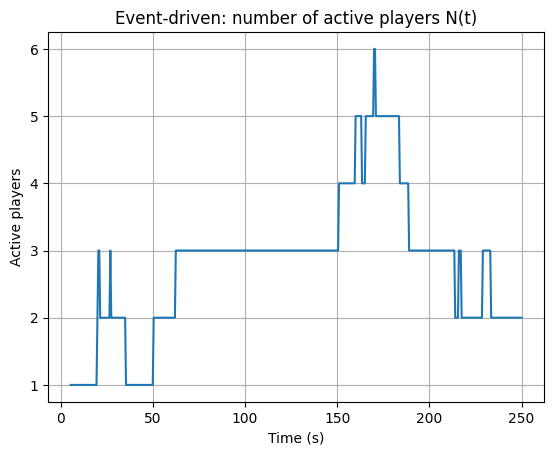

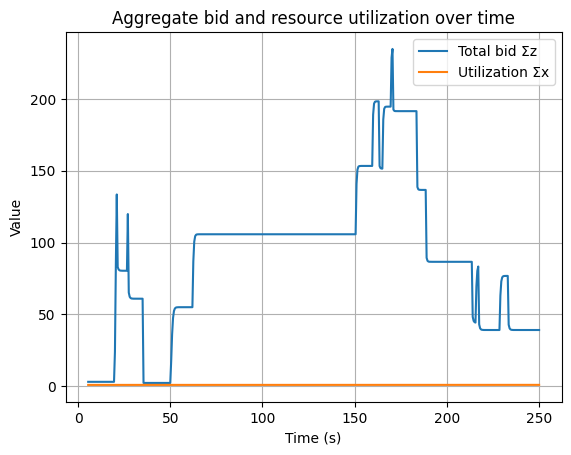

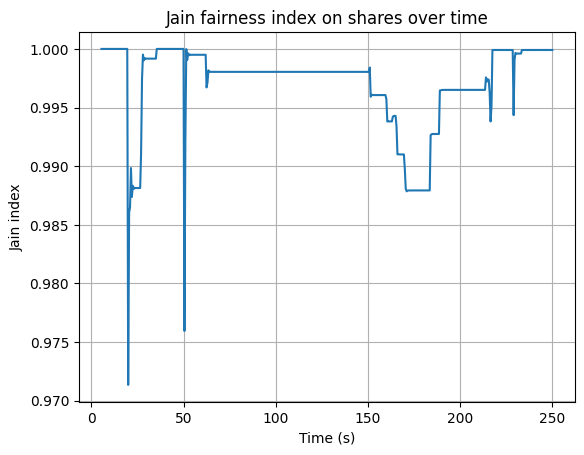

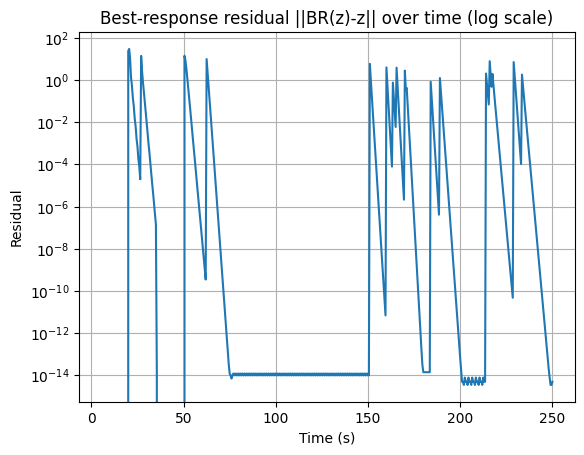

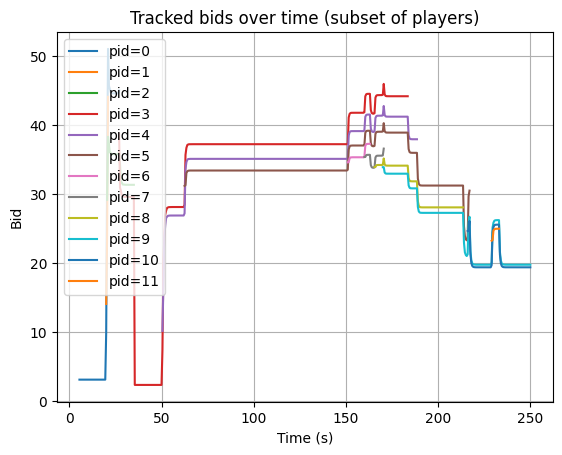

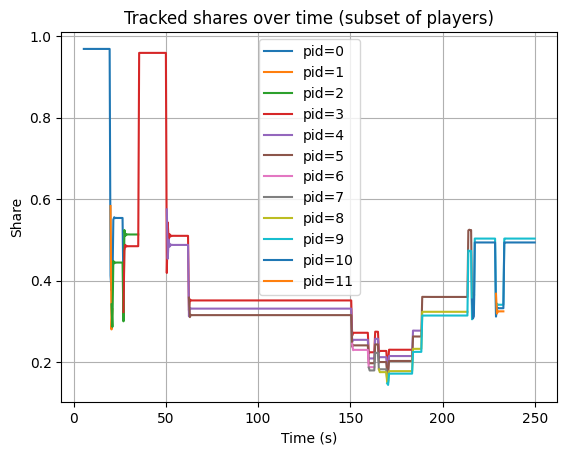

In [67]:
sim = EventDrivenSimulator(
    A_arrivals=0.05,      # arrivals/sec (≈ 1 arrival every 20s)
    B_departures=0.02,    # per-player departure rate (mean lifetime 50s)
    t_end=250.0,
    bid_period=0.5,
    max_players=10,       # "raisonnable"
    alpha=1.0,            # α=1 recommandé (convergence rapide) :contentReference[oaicite:5]{index=5}
    policy="best_response",
    grad_step=0.05,
    lam=1.0,
    delta=0.1,
    gamma=0.4,
).run()

t = np.array(sim.ts)

# 1) N(t)
plt.figure()
plt.plot(t, sim.Ns)
plt.title("Event-driven: number of active players N(t)")
plt.xlabel("Time (s)")
plt.ylabel("Active players")
plt.grid(True)
plt.show()

# 2) Total bids + utilization
plt.figure()
plt.plot(t, sim.total_bids, label="Total bid Σz")
plt.plot(t, sim.utilization, label="Utilization Σx")
plt.title("Aggregate bid and resource utilization over time")
plt.xlabel("Time (s)")
plt.ylabel("Value")
plt.grid(True)
plt.legend()
plt.show()



# 4) Jain fairness on shares
plt.figure()
plt.plot(t, sim.jain)
plt.title("Jain fairness index on shares over time")
plt.xlabel("Time (s)")
plt.ylabel("Jain index")
plt.grid(True)
plt.show()

# 5) BR residual (log) — proche des graphes du papier :contentReference[oaicite:6]{index=6}
plt.figure()
plt.semilogy(t, sim.br_resid)
plt.title("Best-response residual ||BR(z)-z|| over time (log scale)")
plt.xlabel("Time (s)")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

# 6) Tracked bids/shares for a few players (like Fig.1, mais en temps continu)
plt.figure()
for pid in sim.track_ids:
    y = np.array(sim.track_bids[pid], dtype=float)

    # si y est plus court que t, on complète au début avec des NaN
    if len(y) < len(t):
        y = np.concatenate([np.full(len(t) - len(y), np.nan), y])

    plt.plot(t, y, label=f"pid={pid}")

plt.title("Tracked bids over time (subset of players)")
plt.xlabel("Time (s)")
plt.ylabel("Bid")
plt.grid(True)
plt.legend()
plt.show()


plt.figure()
for pid in sim.track_ids:
    y = np.array(sim.track_shares[pid], dtype=float)
    if len(y) < len(t):
        y = np.concatenate([np.full(len(t) - len(y), np.nan), y])
    plt.plot(t, y, label=f"pid={pid}")

plt.title("Tracked shares over time (subset of players)")
plt.xlabel("Time (s)")
plt.ylabel("Share")
plt.grid(True)
plt.legend()
plt.show()



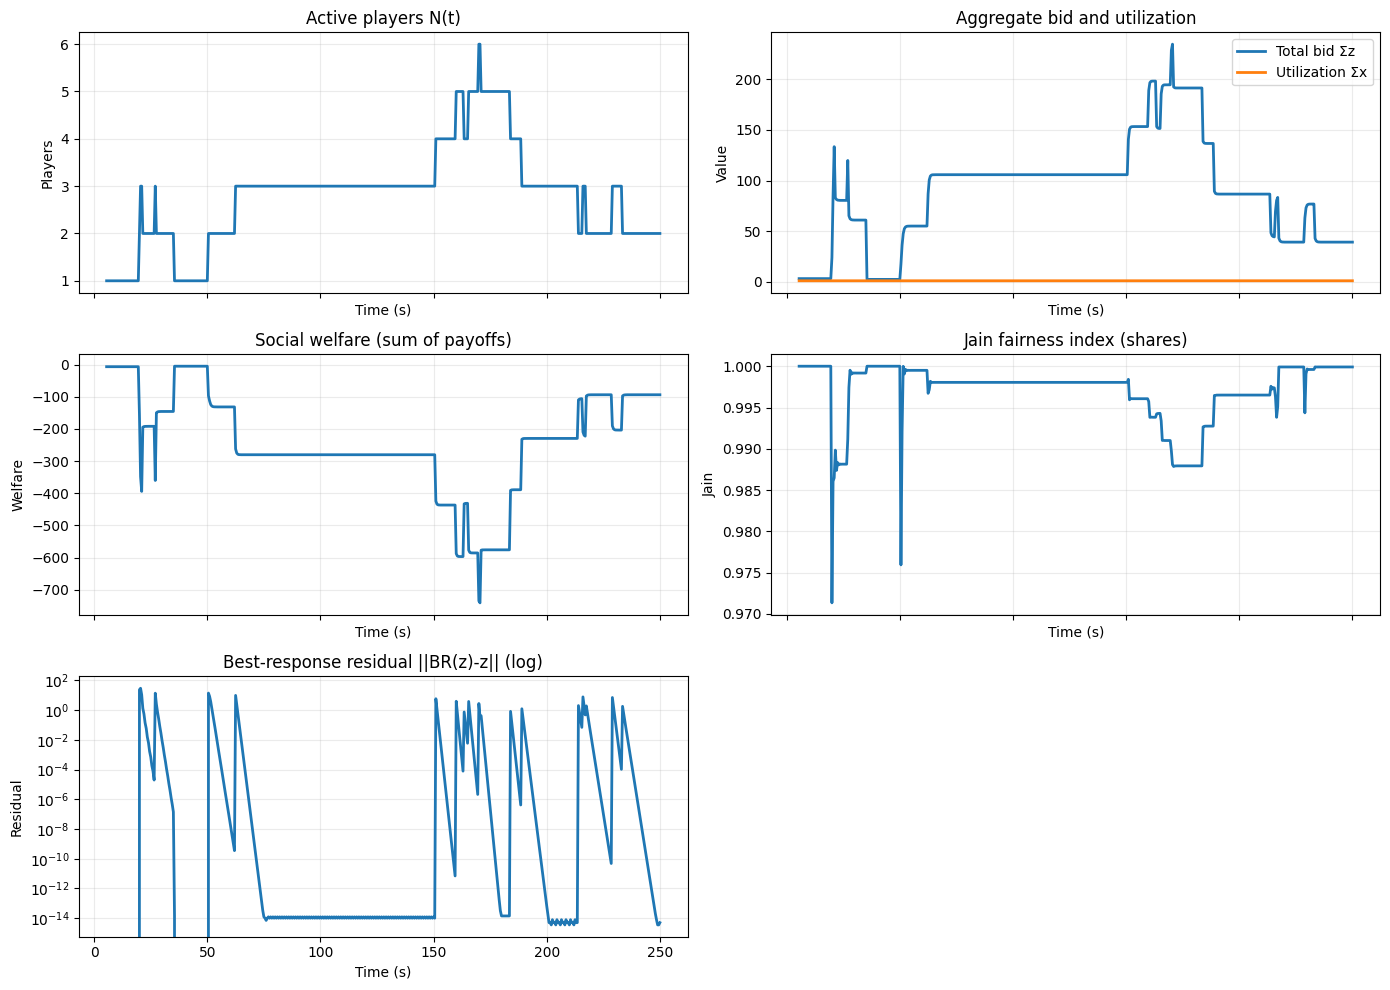

In [68]:
import numpy as np
import matplotlib.pyplot as plt

t = np.array(sim.ts)

def _style_ax(ax, title, xlabel="Time (s)", ylabel=""):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)

fig, axs = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
axs = axs.ravel()

# (1) N(t)
axs[0].plot(t, sim.Ns, linewidth=2)
_style_ax(axs[0], "Active players N(t)", ylabel="Players")

# (2) Total bids + utilization
axs[1].plot(t, sim.total_bids, linewidth=2, label="Total bid Σz")
axs[1].plot(t, sim.utilization, linewidth=2, label="Utilization Σx")
_style_ax(axs[1], "Aggregate bid and utilization", ylabel="Value")
axs[1].legend(loc="upper right")

# (3) Welfare
axs[2].plot(t, sim.welfare, linewidth=2)
_style_ax(axs[2], "Social welfare (sum of payoffs)", ylabel="Welfare")

# (4) Jain
axs[3].plot(t, sim.jain, linewidth=2)
_style_ax(axs[3], "Jain fairness index (shares)", ylabel="Jain")

# (5) BR residual (log)
axs[4].semilogy(t, sim.br_resid, linewidth=2)
_style_ax(axs[4], "Best-response residual ||BR(z)-z|| (log)", ylabel="Residual")

# (6) vide / ou autre metric
axs[5].axis("off")

plt.tight_layout()
plt.show()


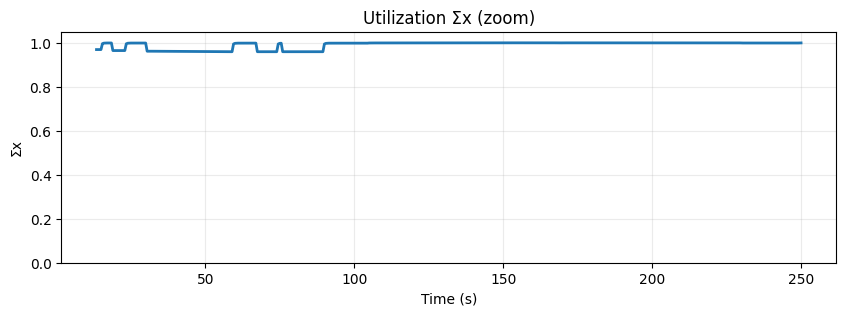

In [65]:
plt.figure(figsize=(10,3))
plt.plot(t, sim.utilization, linewidth=2)
plt.ylim(0, 1.05)
plt.title("Utilization Σx (zoom)")
plt.xlabel("Time (s)")
plt.ylabel("Σx")
plt.grid(True, alpha=0.25)
plt.show()


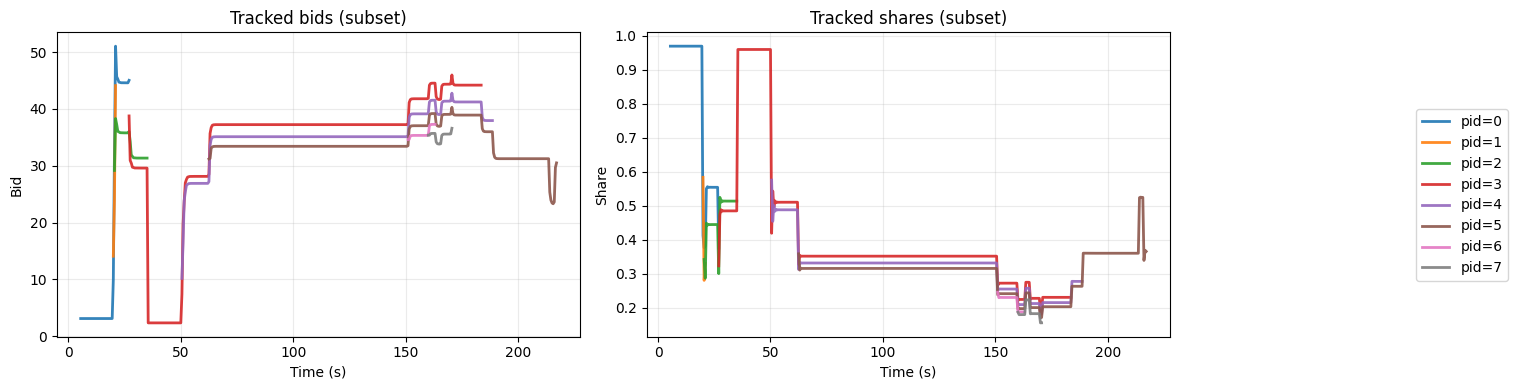

In [69]:
import numpy as np
import matplotlib.pyplot as plt

t = np.array(sim.ts)

# Choisir jusqu'à K joueurs à afficher (par exemple les 6 premiers trackés)
K = 8
pids = sim.track_ids[:K]

def pad(y, L):
    y = np.array(y, dtype=float)
    if len(y) < L:
        y = np.concatenate([np.full(L - len(y), np.nan), y])
    return y

fig, axs = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

# Bids
for pid in pids:
    y = pad(sim.track_bids[pid], len(t))
    axs[0].plot(t, y, linewidth=2, alpha=0.9, label=f"pid={pid}")
axs[0].set_title("Tracked bids (subset)")
axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("Bid")
axs[0].grid(True, alpha=0.25)

# Shares
for pid in pids:
    y = pad(sim.track_shares[pid], len(t))
    axs[1].plot(t, y, linewidth=2, alpha=0.9, label=f"pid={pid}")
axs[1].set_title("Tracked shares (subset)")
axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Share")
axs[1].grid(True, alpha=0.25)

# Légende unique à droite (propre)
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5))

plt.tight_layout(rect=[0, 0, 0.85, 1])  # laisse place à la légende
plt.show()


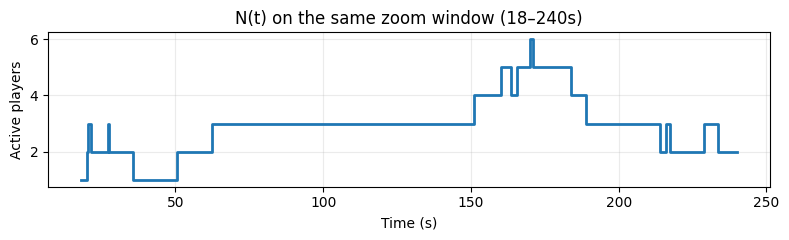

In [70]:
t = np.array(sim.ts)
mask = (t >= 18) & (t <= 240)

plt.figure(figsize=(8,2.5))
plt.step(t[mask], np.array(sim.Ns)[mask], where="post", linewidth=2)
plt.title("N(t) on the same zoom window (18–240s)")
plt.xlabel("Time (s)")
plt.ylabel("Active players")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [53]:
import numpy as np

target = 180.0

snap_t = np.array([rows[0]["t"] for rows in sim.snapshots if rows])  # temps des snapshots
k = int(np.argmin(np.abs(snap_t - target)))

rows = sim.snapshots[k]
active_pids = [r["pid"] for r in rows]

print("closest snapshot t =", rows[0]["t"], "active pids =", active_pids)



closest snapshot t = 180.0 active pids = [11]
